In [1]:
from umap import UMAP
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from scipy.spatial.transform import Rotation as R
from scipy.spatial.distance import pdist
from scipy.stats import wilcoxon
from pyDRMetrics.pyDRMetrics import *
from itertools import product
from joblib import Parallel, delayed
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
pio.renderers.default = "browser"

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import plot_embedding, plot_interactive_embedding
from utils.analysis import rotate_umap, get_user_input

# UMAP Hyperparameter Investigation
The parameters were selected such that the dimensionality-reduced space exhibits a distinct topology. Main parameters to tune:
- **min_dist**: Increasing the minimum distance between points caused the data points to spread further apart diluting finer topologies. 
- **n_neighbors**: A lower number of neighbours led to a more curled up structure while a higher number unfolded it. Increasing the parameter to more than 20 did not further change the embedding significantly.
- **n_components**: The number of dimensions of the embedding.

In [2]:
# Load data
df_minmax = pd.read_csv(f"{config.output_dir}wide_table_knn_minmax.csv")
df_robust = pd.read_csv(f"{config.output_dir}wide_table_knn_robust.csv")
df_dict = {"minmax": df_minmax, "robust": df_robust}

# Scale data
minmax_scaler = MinMaxScaler().fit(df_minmax[config.parameters])
X_m = pd.DataFrame(minmax_scaler.transform(df_minmax[config.parameters]), columns=config.parameters)

# Robust scaler
robust_scaler = RobustScaler().fit(df_robust[config.parameters])
X_r = pd.DataFrame(robust_scaler.transform(df_robust[config.parameters]), columns=config.parameters)

X_dict = {"minmax": X_m, "robust": X_r}

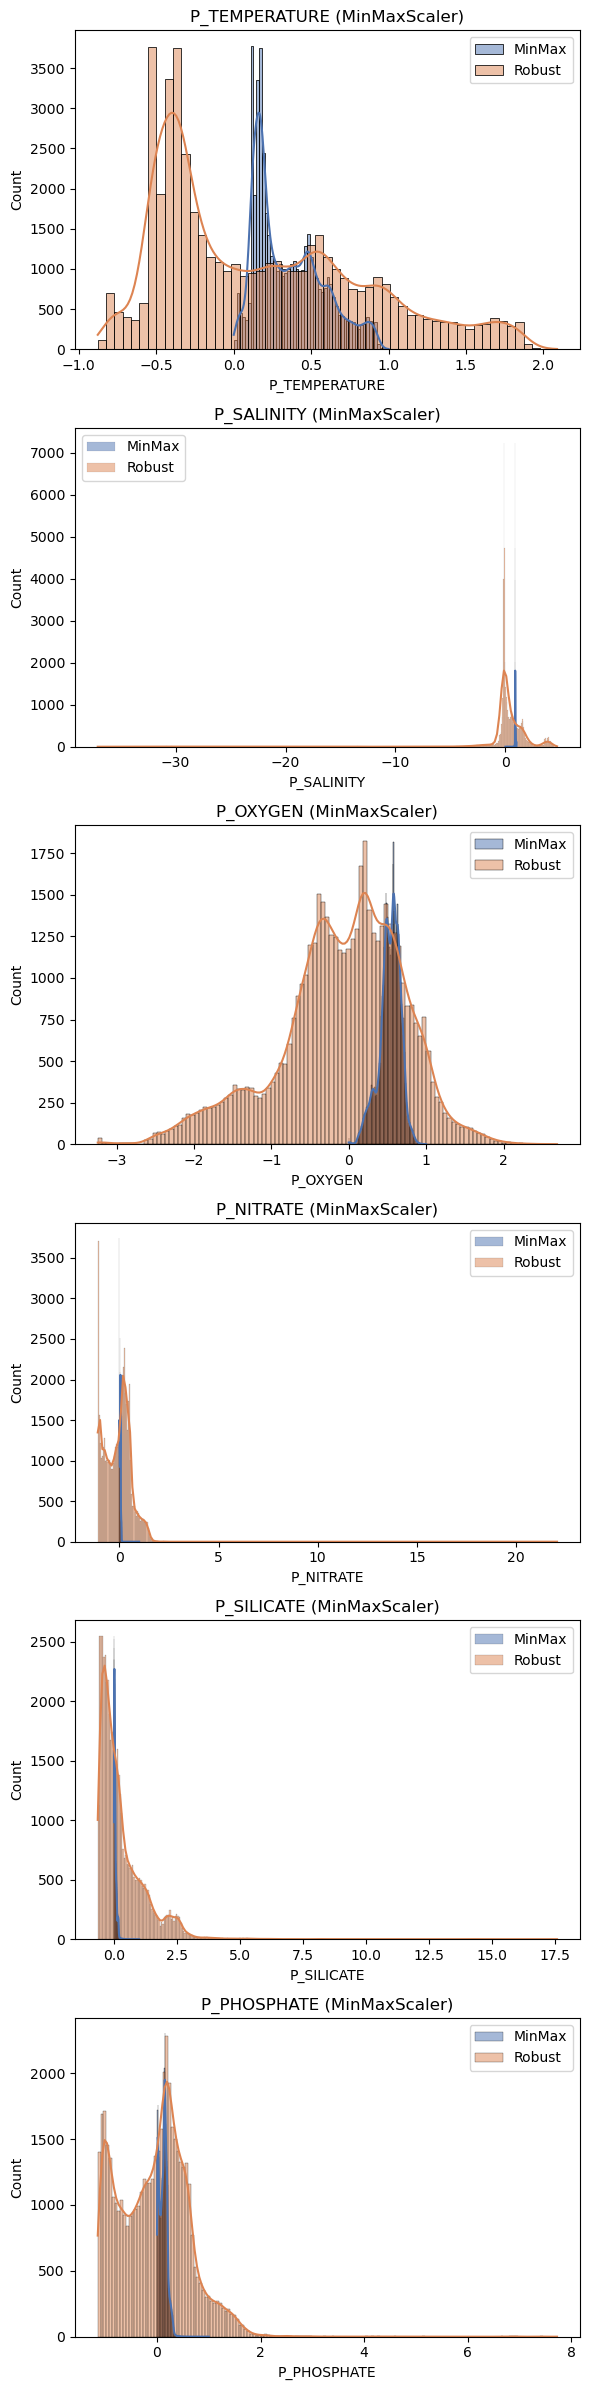

In [3]:
# Compare scald distributions
fig, axes = plt.subplots(nrows=len(config.parameters), ncols=1, figsize=(6, 4 * len(config.parameters)))

for i, feature in enumerate(config.parameters):
    sns.histplot(X_dict["minmax"][feature], ax=axes[i], color="#4C72B0", kde=True, label="MinMax")
    sns.histplot(X_dict["robust"][feature], ax=axes[i], color="#DD8452", kde=True, label="Robust")
    axes[i].set_title(f"{feature} (MinMaxScaler)")
    axes[i].legend()

plt.tight_layout()
plt.show()

# Initial Visual Impressions

In [21]:
# Compute UMAP embeddings with differing hyperparameters
param_combos = [{"min_dist": 0.0, "n_components": 3, "n_neighbors":20, "metric": "euclidean"}, 
                {"min_dist": 0.1, "n_components": 3, "n_neighbors":20, "metric": "euclidean"}, 
                {"min_dist": 0.5, "n_components": 3, "n_neighbors":20, "metric": "euclidean"},
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":5, "metric": "euclidean"},
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":100, "metric": "euclidean"}, 
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":40, "metric": "mahalanobis"}, 
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":20, "metric": "braycurtis"}, 
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":20, "metric": "cosine"} 
               ]

scaler = minmax
min_dist =  0.0
n_components = 3
n_neighbors = 100
metric = euclidean


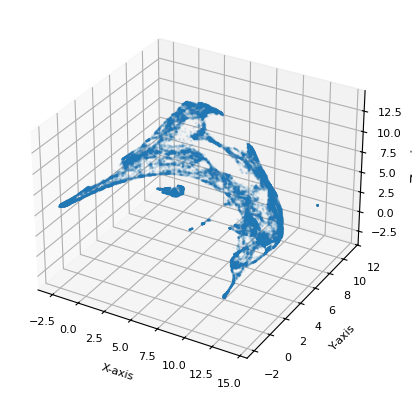

Rotate? y/n y


  y


x rotation:  0
y rotation:  0
z rotation:  180
factor:  -1


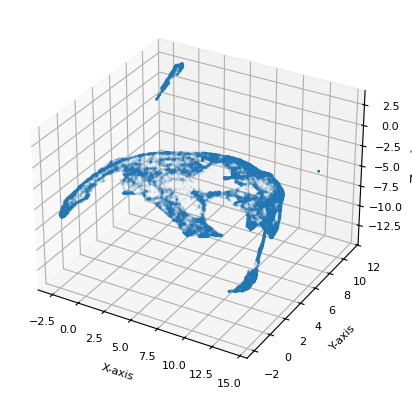

Rotate? y/n y


  y


x rotation:  180
y rotation:  180
z rotation:  0
factor:  1


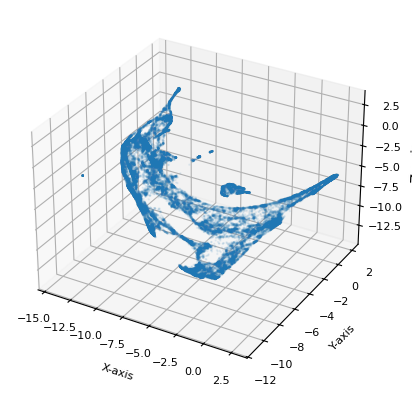

Rotate? y/n y


  y


x rotation:  180
y rotation:  0
z rotation:  0
factor:  -1


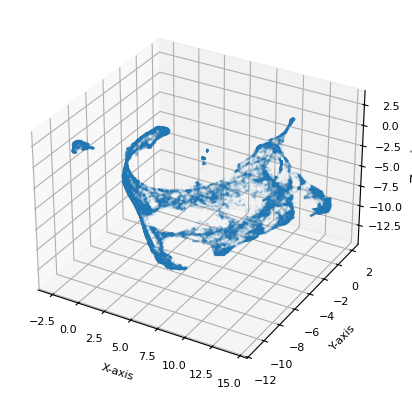

Rotate? y/n y


  y


x rotation:  0
y rotation:  0
z rotation:  180
factor:  1


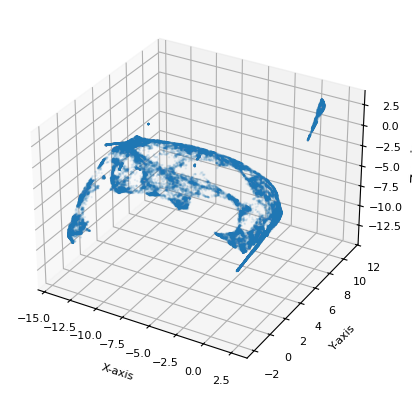

Rotate? y/n n


  n


In [22]:
# Iterate over combinations (and repeat combination until plot has correct rotation for final plot)
embeddings = []

for scaler_name, data in X_dict.items():
    if scaler_name == "robust": 
        continue
        
    for umap_kwargs in param_combos: 
        print(f"scaler = {scaler_name}\nmin_dist =  {umap_kwargs['min_dist']}\nn_components = {umap_kwargs['n_components']}\nn_neighbors = {umap_kwargs['n_neighbors']}\nmetric = {umap_kwargs['metric']}")
    
        # Compute and plot embedding
        embedding = UMAP(**umap_kwargs).fit_transform(data)
        umap_new = get_user_input(embedding)
        # plot_embedding(umap_new, figsize=(4, 4), dpi=300, save_as=None)
        
        # Append to results
        embeddings.append({"embedding": [umap_new], 
                           "scaler": [scaler_name], 
                           "min_dist": umap_kwargs["min_dist"], 
                           "n_neighbors": umap_kwargs["n_neighbors"], 
                           "metric": umap_kwargs["metric"], 
                           "n_components": umap_kwargs["n_components"]})

In [23]:
# Save embeddings (for later plots)
for info in embeddings:
    e = info["embedding"]
    s = info["scaler"][0]
    n_neighbors = info["n_neighbors"]
    min_dist = info["min_dist"]
    metric = info["metric"]
    n_components = info["n_components"]
    np.save(f"{config.output_dir_umap}/{s}/embedding_n_neighbors{n_neighbors}_min_dist{min_dist}_metric{metric}_n_components{n_components}.npy", e)

# Compute Metrics

In [4]:
def umap_grid_search(X_in, param_grid, subsample_size_metrics=2000, iteration=0, scaler_name="minmax", out_dir="umap_metrics_report", n_jobs=-1):
    """ Perform grid search over hyperparameters for UMAP, store results (diagrams and CSV) in the specified directory. """
    # Create output dir if it does not exist yet
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    # Prepare parameter combinations
    param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

    # Subsample once for metrics
    X_metrics = resample(X_in, n_samples=subsample_size_metrics)  # , random_state=random_state)

    def evaluate_umap(umap_hyps):  # n_neighbors, min_dist, metric):
        # Compute embedding
        umap_model = UMAP(**umap_hyps)
        embedding = umap_model.fit_transform(X_metrics)
        try:
            Xr = umap_model.inverse_transform(embedding)
        except:
            Xr = None  # Some UMAP configurations don't support inverse_transform

        # Compute metrics
        drm = DRMetrics(X_metrics, embedding, Xr)

        return {**umap_hyps, **{"Qlocal": drm.Qlocal, "Qglobal": drm.Qglobal, "AUC_T": drm.AUC_T, "AUC_C": drm.AUC_C, "iteration": iteration, "scaler": scaler_name}}

    # Parallel execution
    print(f"Running UMAP grid search on {len(param_combinations)} configurations...")
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_umap)(h) for h in tqdm(param_combinations, position=0, leave=True, desc="UMAP Evaluation")
    )

    # Save results
    df = pd.DataFrame(results)
    df.to_csv(f"{out_dir}/umap_grid_metrics_exp{scaler_name}_iteration{iteration}.csv", index=False)

    print(f"Grid search complete. Results saved in '{out_dir}'\n")

    return df


In [5]:
def plot_shepard(X_sub, y_sub, save_as=None, dpi=300, figsize=(8, 6)):
    """ Plot Shepard diagram. """

    # Compute pairwise distances
    print("Compute pairwise distances...")
    x = pdist(X_sub)
    y = pdist(y_sub)

    # Compute correlation
    corr = round(np.corrcoef(x, y).mean(), 2)
    print(f"Mean correlation between high and low dimenaionsal distances: {corr}")

    # Fit linear regression
    print("Compute linear regression...")
    reg = LinearRegression().fit(x.reshape(-1, 1), y)
    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = reg.predict(x_line)

    # Plot Shepard diagram + regression line
    print("Plotting...")
    plt.figure(figsize=figsize)
    plt.hexbin(x, y, gridsize=200, cmap='viridis', bins='log')
    plt.plot(x_line, y_line, color='red', lw=2, label='Linear trend')
    plt.xlabel("High-dimensional (scaled) distances")
    plt.ylabel("Low-dimensional distances")
    plt.colorbar(label='log(count)')
    plt.legend()
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=dpi)
    plt.show()

    
def plot_qs(df_display, save_as=None):
    """ Qlocal vs Qglobal plot. """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_display, x="Qglobal", y="Qlocal", hue="metric", style="min_dist", size="n_neighbors", palette="tab10")
    plt.xlabel("Qglobal")
    plt.ylabel("Qlocal")
    plt.title("UMAP Hyperparameter Grid: Qlocal vs Qglobal")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as)
    plt.show()


def plot_qs_interactive(df_display, save_as=None):
    """ Interactive scatter Qlocal vs. Qglobal plot.  """
    fig = px.scatter(
        df_display,
        x="Qglobal",
        y="Qlocal",
        color="metric",
        size="n_neighbors",
        symbol="min_dist",
        title="Qlocal vs Qglobal by UMAP parameters",
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    
    # Update layout for axis labels and margins
    fig.update_layout(
        xaxis=dict(title="Qglobal"),
        yaxis=dict(title="Qlocal"),
        legend_title="Metric",
        margin=dict(l=40, r=40, t=40, b=40),
        width=1000, height=1000
    )
    if save_as:
        fig.write_html(save_as)
    fig.show() 


In [16]:
for i in range(20): 
    for scaler_name, X in X_dict.items():
        print(scaler_name)
        X = X.to_numpy().astype(np.float32)
    
        umap_grid_search(X,
            param_grid={
                "n_neighbors": [5, 10, 20, 30, 50, 100, 150],
                "min_dist":  [0.0, 0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 0.99],
                "metric": ["euclidean", "mahalanobis", "manhattan", "cosine", "chebyshev"],
                "n_components": [3]
            },
            iteration=i,
            scaler_name=scaler_name,
            subsample_size_metrics=2000,
            out_dir=f"{config.output_dir_umap}/{scaler_name}",
            n_jobs=4  # Use -1 for all cores
        )
        

minmax
Running UMAP grid search on 315 configurations...


UMAP Evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 315/315 [38:52<00:00,  7.40s/it]


Grid search complete. Results saved in 'output_minmax//umap//minmax'

robust
Running UMAP grid search on 315 configurations...


UMAP Evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 315/315 [37:18<00:00,  7.11s/it]


Grid search complete. Results saved in 'output_minmax//umap//robust'

minmax
Running UMAP grid search on 315 configurations...


...

Grid search complete. Results saved in 'output_minmax//umap//robust'

minmax
Running UMAP grid search on 315 configurations...


UMAP Evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 315/315 [36:58<00:00,  7.04s/it]


Grid search complete. Results saved in 'output_minmax//umap//minmax'

robust
Running UMAP grid search on 315 configurations...


UMAP Evaluation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 315/315 [37:26<00:00,  7.13s/it]


Grid search complete. Results saved in 'output_minmax//umap//robust'



In [40]:
# Combine results into one file
df_results = []

for i in range(20): 
    for scaler_name, X in X_dict.items():
        temp = pd.read_csv(f"{config.output_dir_umap}/{scaler_name}/umap_grid_metrics_exp{scaler_name}_iteration{i}.csv")
        df_results.append(temp)

df_results = pd.concat(df_results)
df_results.to_csv(f"{config.output_dir_umap}/umap_grid_metrics.csv", index=False)

# Compare Scalers

In [29]:
# Load score results
df = pd.read_csv(f"{config.output_dir_umap}/umap_grid_metrics.csv")

In [19]:
# Check if differences between minmax and robust scaler are statistically significant
metrics = ["Qlocal", "Qglobal", "AUC_T", "AUC_C"]
for metric in metrics:
    print(f"\nComparing {metric}:")
    try:
        stat, p = wilcoxon(df[df.scaler == "minmax"][metric], df[df.scaler == "robust"][metric])
        print(f"Wilcoxon test: W={stat:.3f}, p={p:.4f}")
    except ValueError:
        print("Wilcoxon test could not be performed (not enough non-zero differences).")


Comparing Qlocal:
Wilcoxon test: W=582834.000, p=0.0000

Comparing Qglobal:
Wilcoxon test: W=335343.000, p=0.0000

Comparing AUC_T:
Wilcoxon test: W=123546.000, p=0.0000

Comparing AUC_C:
Wilcoxon test: W=974846.000, p=0.0000


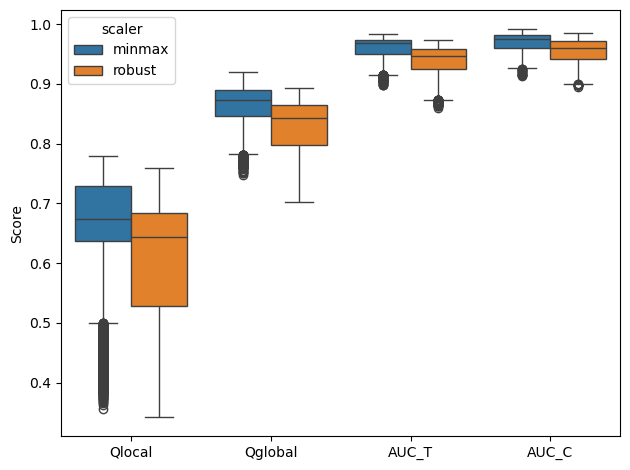

In [20]:
# Overall comparison across validation metrics
melted = df.melt(
    id_vars=['scaler', 'iteration', 'n_neighbors', 'min_dist', 'metric', 'n_components'],
    value_vars=metrics,
    var_name='val_metric',
    value_name='score')

sns.boxplot(melted, x="val_metric", y="score", hue="scaler")
plt.ylabel("Score")
plt.xlabel("")
plt.tight_layout()
plt.savefig(f"{config.output_dir_plots}/scaler_comparison.png")
plt.show()

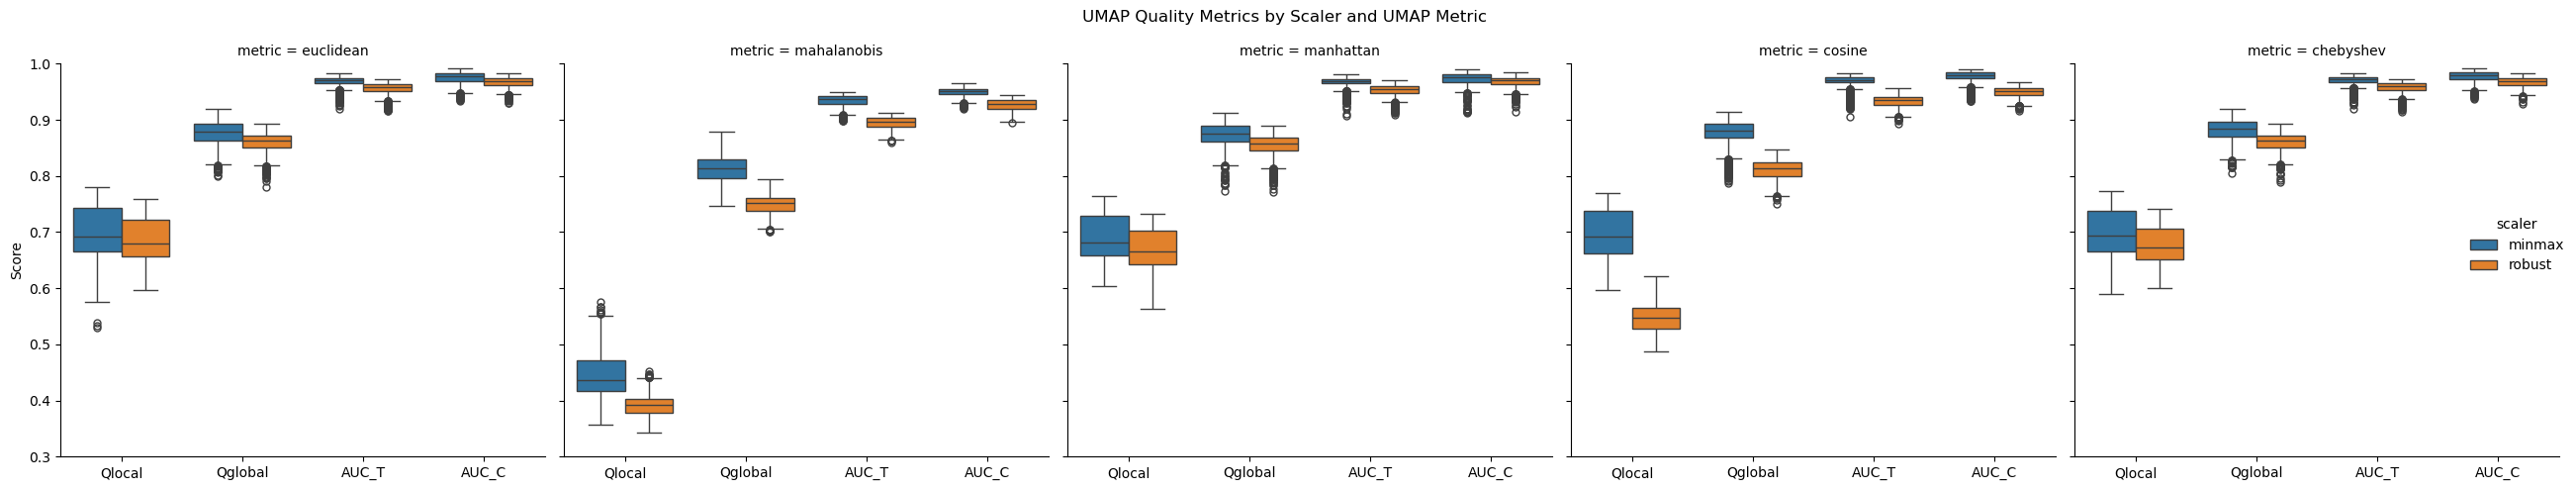

In [21]:
# Overall comparison across validation metrics per distance metric
g = sns.catplot(melted, kind="box",
    x="val_metric",
    y="score",
    hue="scaler",
    col="metric", errorbar='sd')

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("UMAP Quality Metrics by Scaler and UMAP Metric")
g.set_axis_labels("", "Score")
g.set(ylim=(np.floor(melted.score.min()*10)/10, 1.0))
plt.tight_layout()

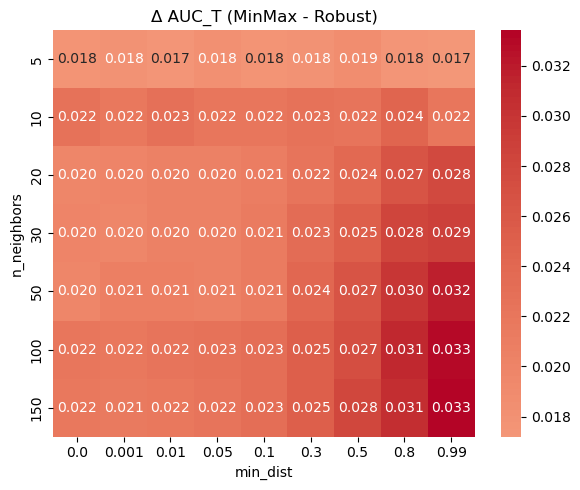

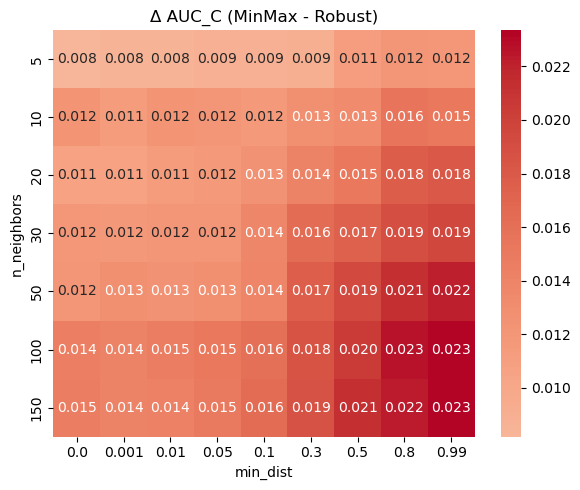

In [22]:
# Compare AUC_C and AUC_T
df_wide = df.pivot_table(
    index=["iteration", "n_neighbors", "min_dist", "metric", "n_components"],
    columns="scaler",
    values=["AUC_T", "AUC_C"]
)

df_wide.columns = [f"{metric}_{scaler}" for metric, scaler in df_wide.columns]
df_wide = df_wide.reset_index()

# Compute differences 
df_wide['delta_AUC_T'] = df_wide['AUC_T_minmax'] - df_wide['AUC_T_robust']
df_wide['delta_AUC_C'] = df_wide['AUC_C_minmax'] - df_wide['AUC_C_robust']

# Compute mean
agg = df_wide.groupby(["n_neighbors", "min_dist"], as_index=False).mean(numeric_only=True)

# Plot
for metric in ["AUC_T", "AUC_C"]:
    pivot = agg.pivot(index="n_neighbors", columns="min_dist", values=f"delta_{metric}")
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".3f")
    plt.title(f"Δ {metric} (MinMax - Robust)")
    plt.xlabel("min_dist")
    plt.ylabel("n_neighbors")
    plt.tight_layout()
    plt.show()

Conclusion: On average and across all distance metrics, the embeddings computed on min-max scaled data outperformed embeddings computed on robustly scaled data. The differences are statistically significant.

# Select Hyperparameters

In [23]:
# Load score results
df = pd.read_csv(f"{config.output_dir_umap}/umap_grid_metrics.csv")

minmax
  Max. Qlocal:      n_neighbors  min_dist     metric  n_components    Qlocal   Qglobal  \
177           30      0.99  euclidean           3.0  0.764403  0.882359   

        AUC_T     AUC_C  iteration  
177  0.965265  0.975942       19.5  


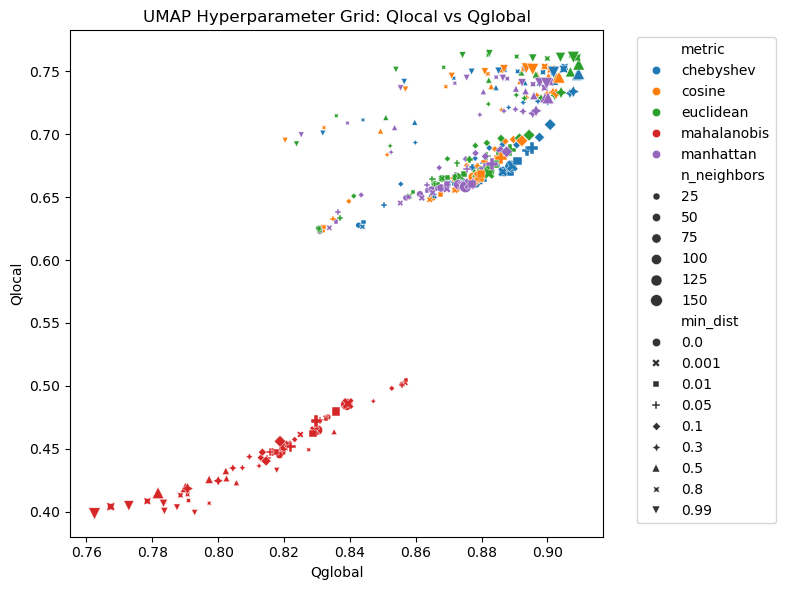

robust
  Max. Qlocal:      n_neighbors  min_dist     metric  n_components    Qlocal   Qglobal  \
172           30       0.8  euclidean           3.0  0.744824  0.865617   

        AUC_T     AUC_C  iteration  
172  0.954068  0.969511       19.5  


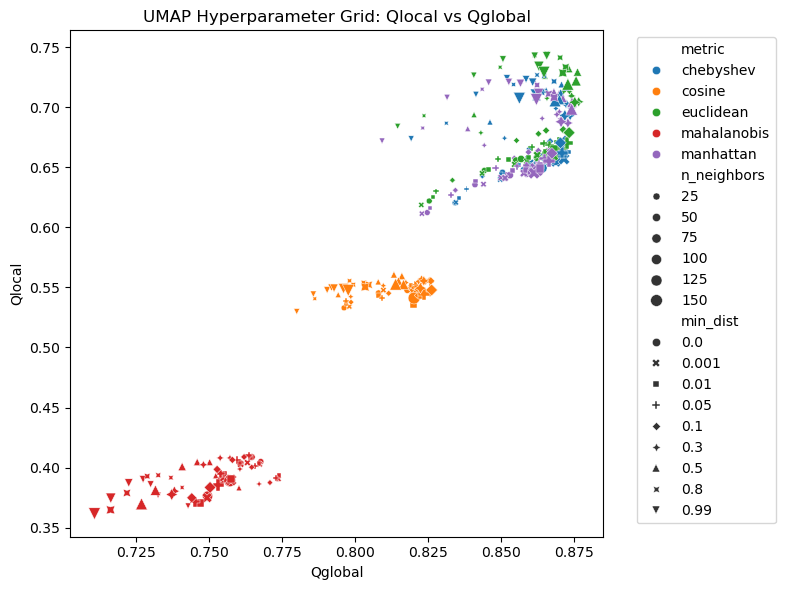

In [41]:
# Plot Qlocal vs Qglobal 

# Iterate over scalers
for scaler_name in df.scaler.unique():
    print(scaler_name)
    # Filter for scaler
    temp = df[df.scaler == scaler_name]

    # Take mean over iterations
    temp = temp.drop("scaler", axis=1).groupby(["n_neighbors", "min_dist", "metric"]).mean().reset_index()

    # Compute max. Qlocal entry
    print(f"  Max. Qlocal: {temp[temp.Qlocal == temp.Qlocal.max()]}")
    
    # Plot Q
    plot_qs(temp, f"{config.output_dir_plots}/qs_plot_{scaler_name}.png")
    plot_qs_interactive(temp, f"{config.output_dir_plots}/qs_plot_{scaler_name}.html")

In [42]:
df[df.scaler == "minmax"].max()

n_neighbors           150
min_dist             0.99
metric          manhattan
n_components            3
Qlocal           0.779429
Qglobal          0.919428
AUC_T            0.983757
AUC_C             0.99113
iteration              29
scaler             minmax
dtype: object

# Plotting with Final Hyperparameters

In [2]:
# Define final hyperparameter combinations
final_hyps = {"minmax": {"n_neighbors": 20, "min_dist": 0.0, "metric": "euclidean", "n_components": 3}, 
              "robust": {"n_neighbors": 30, "min_dist": 0.8, "metric": "euclidean", "n_components": 3}
             }

In [6]:
# Load score results
df_results = pd.read_csv(f"{config.output_dir_umap}/umap_grid_metrics.csv")

In [7]:
# Print average metrics from hyp tuning
for scaler_name, hyps in final_hyps.items():
    print(scaler_name)
    temp = df_results[(df_results["scaler"] == scaler_name) & (df_results["n_neighbors"] == hyps["n_neighbors"]) & (df_results["min_dist"] == hyps["min_dist"]) & (df_results["metric"] == hyps["metric"]) & (df_results["n_components"] == hyps["n_components"])]
    temp = temp.groupby(["scaler", "n_neighbors", "min_dist", "metric", "n_components"]).agg(["mean", "std"])

    print(f"  Avg. Qglobal = {temp.Qglobal['mean'].values[0]:.2f} +- {temp.Qglobal['std'].values[0]:.4f}\n"
          f"  Avg. Qlocal = {temp.Qlocal['mean'].values[0]:.2f} +- {temp.Qlocal['std'].values[0]:.4f}\n"
          f"  Avg. AUC_T = {temp.AUC_T['mean'].values[0]:.2f} +- {temp.AUC_T['std'].values[0]:.4f}\n"
          f"  Avg. AUC_C = {temp.AUC_C['mean'].values[0]:.2f} +- {temp.AUC_C['std'].values[0]:.4f}\n")

minmax
  Avg. Qglobal = 0.87 +- 0.0085
  Avg. Qlocal = 0.66 +- 0.0143
  Avg. AUC_T = 0.97 +- 0.0042
  Avg. AUC_C = 0.97 +- 0.0073

robust
  Avg. Qglobal = 0.87 +- 0.0078
  Avg. Qlocal = 0.74 +- 0.0069
  Avg. AUC_T = 0.95 +- 0.0058
  Avg. AUC_C = 0.97 +- 0.0058



In [34]:
# Reference embeddings
for scaler_name, hyps in final_hyps.items():
    print(scaler_name)
    df_temp = df_dict[scaler_name]
    X_temp = X_dict[scaler_name].to_numpy()

    # Compute embedding
    print("  Compute UMAP...")
    umap_model = UMAP(**hyps)
    embedding = umap_model.fit_transform(X_temp)

    # Save embedding
    df_temp[["e0", "e1", "e2"]] = embedding
    df_temp.to_csv(f"{config.output_dir_umap}/{scaler_name}/final_embeddings.csv")

minmax
  Compute UMAP...


C:\Users\yvjennig\.conda\envs\ocean_clustering_and_validation\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



robust
  Compute UMAP...


C:\Users\yvjennig\.conda\envs\ocean_clustering_and_validation\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



minmax


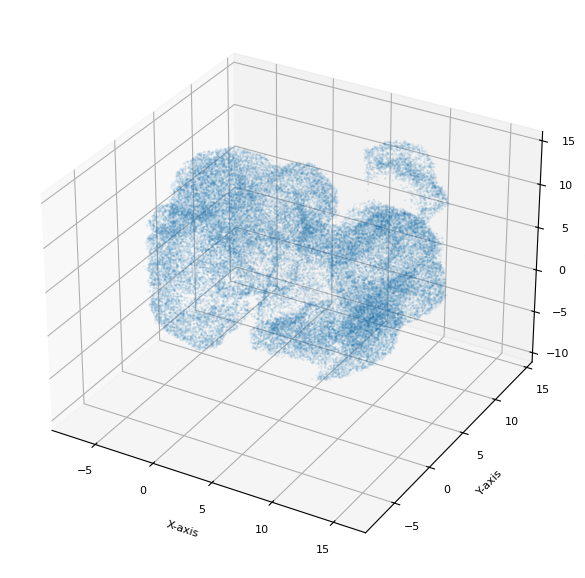

robust


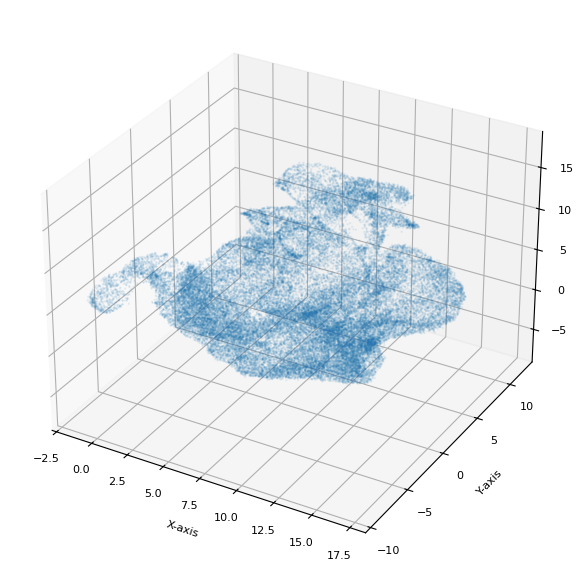

In [35]:
# Plotting
for scaler_name, hyps in final_hyps.items():
    print(scaler_name)
    # Load reference embedding
    df_temp = pd.read_csv(f"{config.output_dir_umap}/{scaler_name}/final_embeddings.csv")

    # Scatter plot
    plot_embedding(df_temp[["e0", "e1", "e2"]], save_as=f"{config.output_dir_plots_high_res}/embedding_{scaler_name}.png", dpi=1000, figsize=(6, 6))
    plot_interactive_embedding(df_temp[["e0", "e1", "e2"]], save_as=f"{config.output_dir_plots}/embedding_{scaler_name}.html")

    # Shepard plot
    plot_shepard(X_dict[scaler_name].to_numpy(), df_temp[["e0", "e1", "e2"]].to_numpy(), save_as=f"{config.output_dir_plots_high_res}/shepard_{scaler_name}.png", dpi=1000, figsize=(8, 6))

minmax


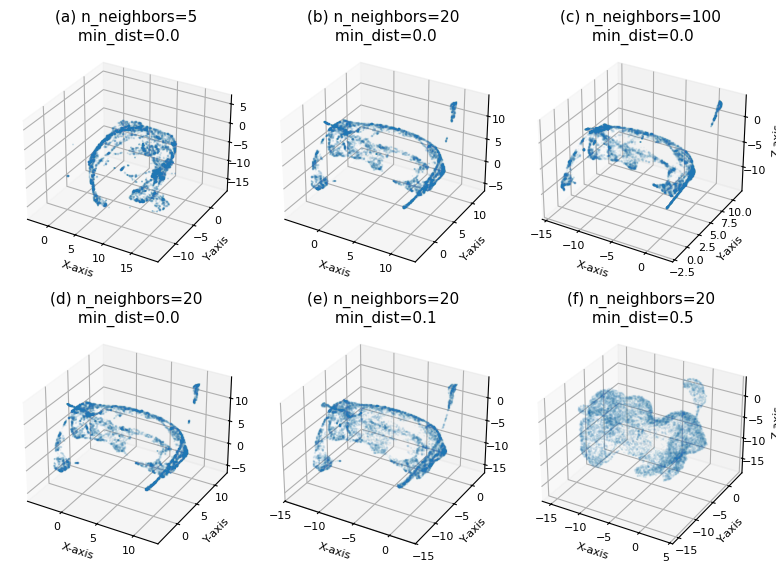

robust


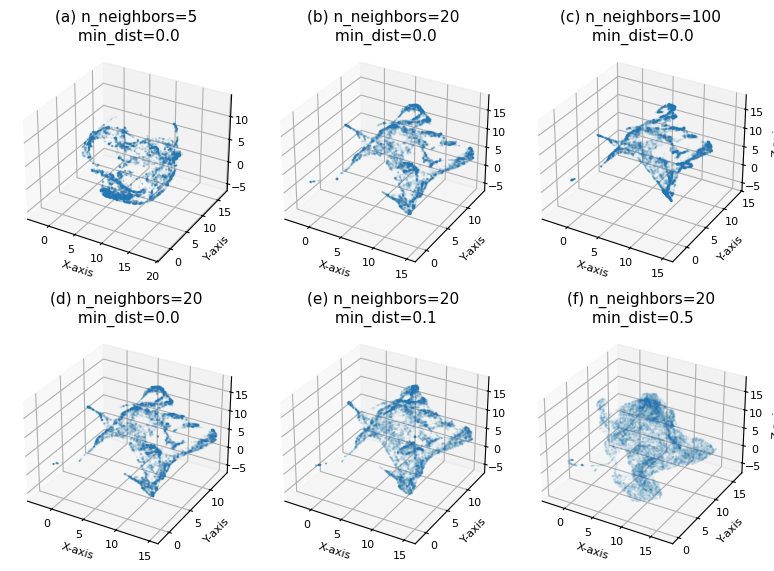

In [26]:
# Hyperparameter comparison plot
pad = 0
alpha = 0.08
size = 0.03
marker = ","
tick_label_size = 8
tick_padding = -3
label_size = 8
label_padding = -6
title_size = 11
subplot_labels = ["a", "b", "c", "d", "e", "f"]

for scaler_name in X_dict.keys():
    print(scaler_name)

    fig, axs = plt.subplots(2, 3, subplot_kw={"projection": "3d"}, figsize=(8.27-pad, (8.27-pad)*0.7))  # A4 size in inches: 8.27 x 11.69
    
    # Plot first row (varying n_neighbors)
    for i, n_neighbors in enumerate([5, 20, 100]):
        min_dist = "0.0"
        i = int(i)
    
        # Load embedding
        e = np.load(f'{config.output_dir_umap}/{scaler_name}/embedding_n_neighbors{n_neighbors}_min_dist{min_dist}_metriceuclidean_n_components3.npy', allow_pickle=True)[0]
    
        axs[0, i].scatter(e[:, 0], e[:, 1], e[:, 2], alpha=alpha, s=size, marker=marker)
        axs[0, i].set_title(f"({subplot_labels[i]}) n_neighbors={n_neighbors}\n min_dist={min_dist}", fontsize=title_size, pad=0)
        axs[0, i].set_xlabel('X-axis', fontsize=label_size, labelpad=label_padding)
        axs[0, i].set_ylabel('Y-axis', fontsize=label_size, labelpad=label_padding)
    
        if i == 2:
            axs[0, i].set_zlabel('Z-axis', fontsize=label_size, labelpad=label_padding)
    
        # Set tick label sizes
        axs[0, i].tick_params(axis='x', labelsize=tick_label_size, pad=tick_padding)
        axs[0, i].tick_params(axis='y', labelsize=tick_label_size, pad=tick_padding)
        axs[0, i].tick_params(axis='z', labelsize=tick_label_size, pad=tick_padding)
    
    # Plot second row (varying min_dist)
    for i, min_dist in enumerate([0.0, 0.1, 0.5]):
        n_neighbors = 20
        i = int(i)
    
        # Load embedding
        e = np.load(f"{config.output_dir_umap}/{scaler_name}/embedding_n_neighbors{n_neighbors}_min_dist{min_dist}_metriceuclidean_n_components3.npy", allow_pickle=True)[0]
    
        axs[1, i].scatter(e[:, 0], e[:, 1], e[:, 2], alpha=alpha, s=size, marker=marker)
        axs[1, i].set_title(f"({subplot_labels[3 + i]}) n_neighbors={n_neighbors}\n min_dist={min_dist}", fontsize=title_size, pad=0)
        axs[1, i].set_xlabel('X-axis', fontsize=label_size, labelpad=label_padding)
        axs[1, i].set_ylabel('Y-axis', fontsize=label_size, labelpad=label_padding)
    
        if i == 2:
            axs[1, i].set_zlabel('Z-axis', fontsize=label_size, labelpad=label_padding)
    
        # Set tick label sizes
        axs[1, i].tick_params(axis='x', labelsize=tick_label_size, pad=tick_padding)
        axs[1, i].tick_params(axis='y', labelsize=tick_label_size, pad=tick_padding)
        axs[1, i].tick_params(axis='z', labelsize=tick_label_size, pad=tick_padding)
    
    plt.subplots_adjust(hspace=1)
    plt.tight_layout()
    #plt.savefig(f"{config.output_dir_plots}umap_hyperparameters.png", dpi=300)
    plt.savefig(f"{config.output_dir_plots_high_res}umap_hyperparameters_{scaler_name}.png", dpi=1000)
    plt.show()

In [ ]:
# # Metrics
# metrics = {}
# for scaler_name, hyps in final_hyps.items():
#     print(scaler_name)
#     # Load reference embedding
#     df_temp = pd.read_csv(f"{config.output_dir_umap}/{scaler_name}/final_embeddings.csv")[["e0", "e1", "e2"]]
#     df_temp = df_temp.sample(frac=0.2)
#     df_scaled_temp = X_dict[scaler_name].loc[df_temp.index]

#     # Compute metrics
#     drm = DRMetrics(df_scaled_temp.to_numpy(), df_temp.to_numpy())
#     metrics[scaler_name] = drm

#     # Print important metrics
#     print(f"  Qglobal = {drm.Qglobal}\n  Qlocal = {drm.Qlocal}\n  AUC_T = {drm.AUC_T}\n  AUC_C = {drm.AUC_C}")